# Chapter 13 - Nonlinear Twiss

With Truncated Power Series Algebra (TPSA) tools, Twiss parameters in SciBmad can be expressed as Taylor series in selected variables. In this chapter, the selected variable is mainly the momentum deviation $\delta$.

For example, a beta function can be represented as

$$
\beta(s,\delta) = \beta_0(s) + \frac{\partial \beta}{\partial \delta}(s)\delta + \frac{1}{2!}\frac{\partial^2 \beta}{\partial \delta^2}(s)\delta^2 + \cdots.
$$

The Taylor coefficients can then be read directly from the TPSA objects returned by `twiss`. This is different from a finite-difference scan: the derivatives are part of the map-based calculation itself.

We begin by loading the ESR v6.3.1 lattice used by the SciBmad nonlinear Twiss example.

In [ ]:
# Activate the shared tutorial environment.
# Run setup_environment.ipynb first on a new installation or after dependencies change.
import Pkg
Pkg.activate(@__DIR__)


In [54]:
using SciBmad
using CairoMakie
using LaTeXStrings

set_theme!(theme_latexfonts())

In [55]:
if !isdefined(Main, :PhaseRef) && isdefined(Main, :PhaseReference)
    const PhaseRef = PhaseReference
end

ring = include(joinpath(pwd(), "lattices", "chapter_13", "esr-v6.3.1.jl"))

Beamline:
 species_ref = electron
 pc_ref = 1.784626263654482e10

  Index   Name      Kind         s [m]   
  1       IP6       Marker       0
  2       DRIFT0    Drift        0.0
  3       Q1ER_6    Quadrupole   5.3
  4       DRIFT1    Drift        7.1
  5       Q2ER_6    Quadrupole   7.6
  6       DRIFT2    Drift        9.0
  7       D2ER_6    SBend        16.75
  8       DRIFT3    Drift        22.2501
  9       SQ3ER_6   Quadrupole   42.0647
  10      DRIFT4    Drift        42.3147
  11      Q3ER_6    Quadrupole   42.4647
  12      DRIFT5    Drift        43.0647
  13      SQ4ER_6   Quadrupole   46.5647
  14      DRIFT6    Drift        46.8147
  15      Q4ER_6    Quadrupole   46.9647
  16      DRIFT7    Drift        47.5647
  17      SQ5ER_6   Quadrupole   51.0647
  18      DRIFT8    Drift        51.3147
  19      Q5ER_6    Quadrupole   51.4647
  ⋮       ⋮         ⋮            ⋮

                         6251 rows omitted

## 13.1 Initializing Twiss

A standard `twiss` call returns the coupled Twiss functions around the ring. The table columns `beta_1` and `beta_2` are the two transverse normal-mode beta functions in the Teng-Edwards coupling formalism.

In [56]:
tw = twiss(ring)
t = tw.table

Table with 21 columns and 6271 rows:
      beamline_index  name     s        phi_1                 beta_1    ⋯
    ┌────────────────────────────────────────────────────────────────────
 1  │ 1               IP6      0.0      TPS64{Dynamic}:
Desc…  0.589999  ⋯
 2  │ 2               DRIFT0   0.0      TPS64{Dynamic}:
Desc…  0.589999  ⋯
 3  │ 3               Q1ER_6   5.3      TPS64{Dynamic}:
Desc…  48.2002   ⋯
 4  │ 4               DRIFT1   7.1      TPS64{Dynamic}:
Desc…  151.952   ⋯
 5  │ 5               Q2ER_6   7.6      TPS64{Dynamic}:
Desc…  220.652   ⋯
 6  │ 6               DRIFT2   9.0      TPS64{Dynamic}:
Desc…  333.073   ⋯
 7  │ 7               D2ER_6   16.75    TPS64{Dynamic}:
Desc…  233.455   ⋯
 8  │ 8               DRIFT3   22.2501  TPS64{Dynamic}:
Desc…  173.733   ⋯
 9  │ 9               SQ3ER_6  42.0647  TPS64{Dynamic}:
Desc…  34.08     ⋯
 10 │ 10              DRIFT4   42.3147  TPS64{Dynamic}:
Desc…  33.0731   ⋯
 11 │ 11              Q3ER_6   42.4647  TPS64{Dynamic}:
Desc…  32

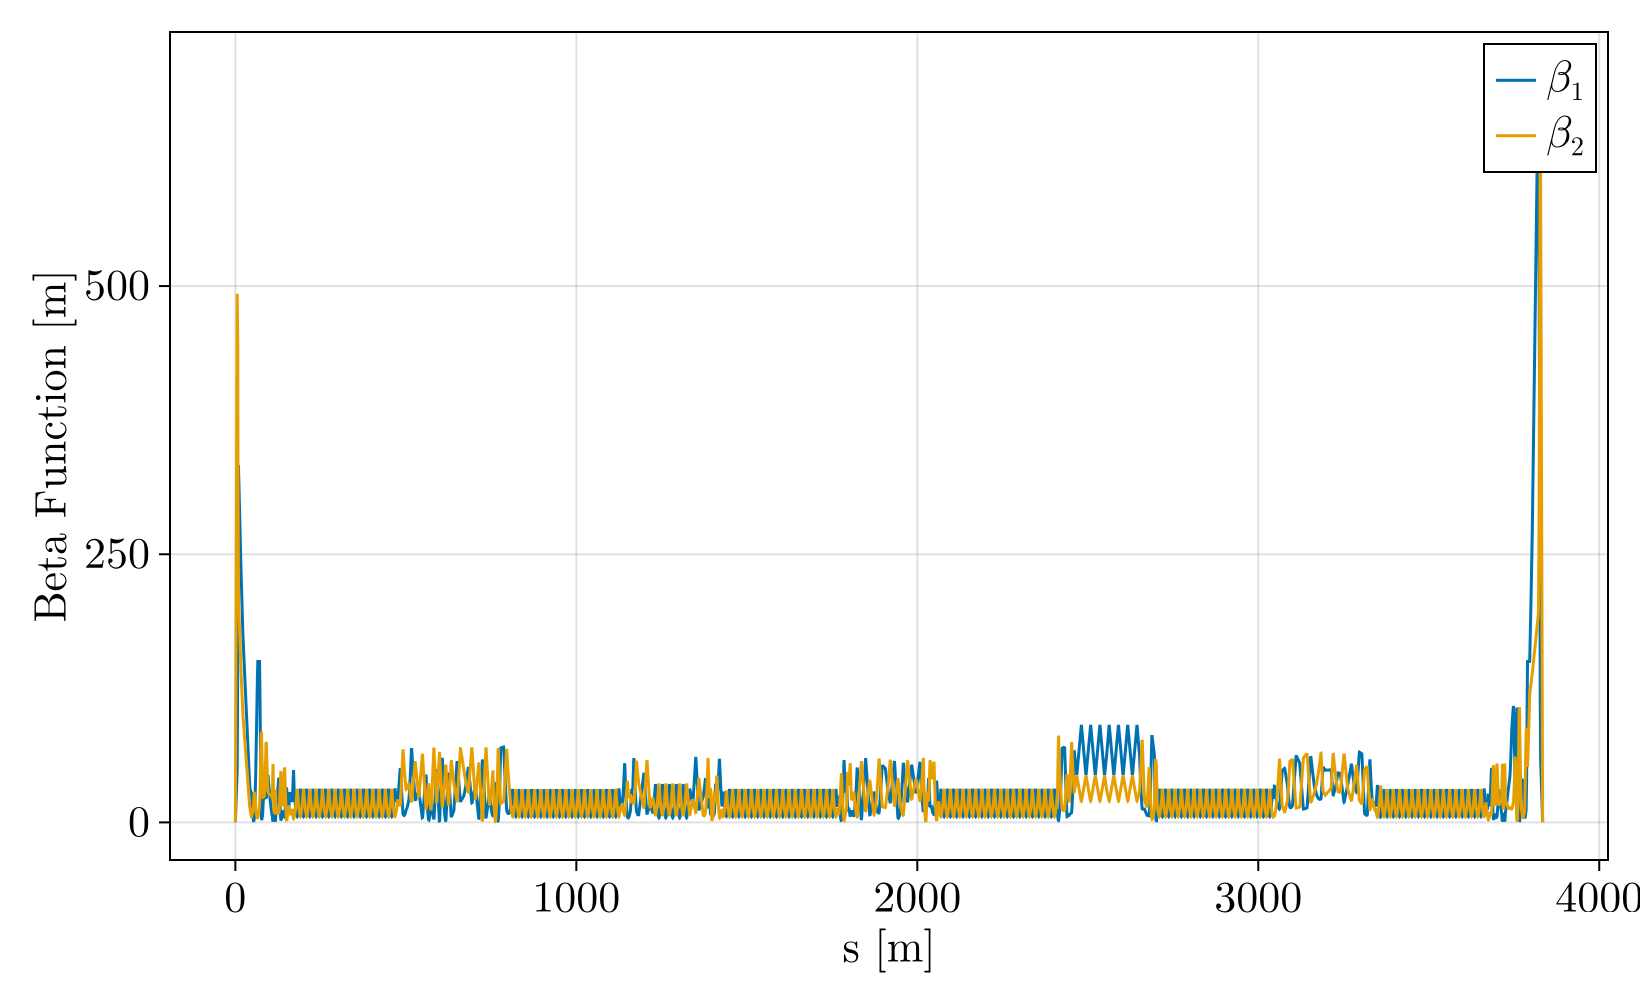

In [57]:
fig = Figure(fontsize=22, size=(820, 500))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Beta Function [m]")

lines!(ax, t.s, t.beta_1, label=L"\beta_1")
lines!(ax, t.s, t.beta_2, label=L"\beta_2")
axislegend(ax, position=:rt)

fig

## 13.2 TPSA Operations

The closed orbit returned by `twiss` is also a TPSA object. At a fixed location, it can be interpreted as a Taylor series in the phase-space variables. For this lattice, the last coordinate is the momentum deviation $\delta$.

$$
x_{co}(\delta) = x_0 + \eta_x\delta + \frac{1}{2!}\frac{\partial \eta_x}{\partial \delta}\delta^2 + \cdots.
$$

The monomial index `[0, 0, 0, 0, 0, 1]` extracts the coefficient of $\delta$. Therefore, it gives the periodic dispersion $\eta_x$.

In [58]:
# Inspect the closed orbit at the beginning of the ring.
t.orbit_x[1]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
2.4442493994496515E-016    0     0 0  0 0  0 0
4.7436543508558284E-008    1     0 0  0 0  0 1


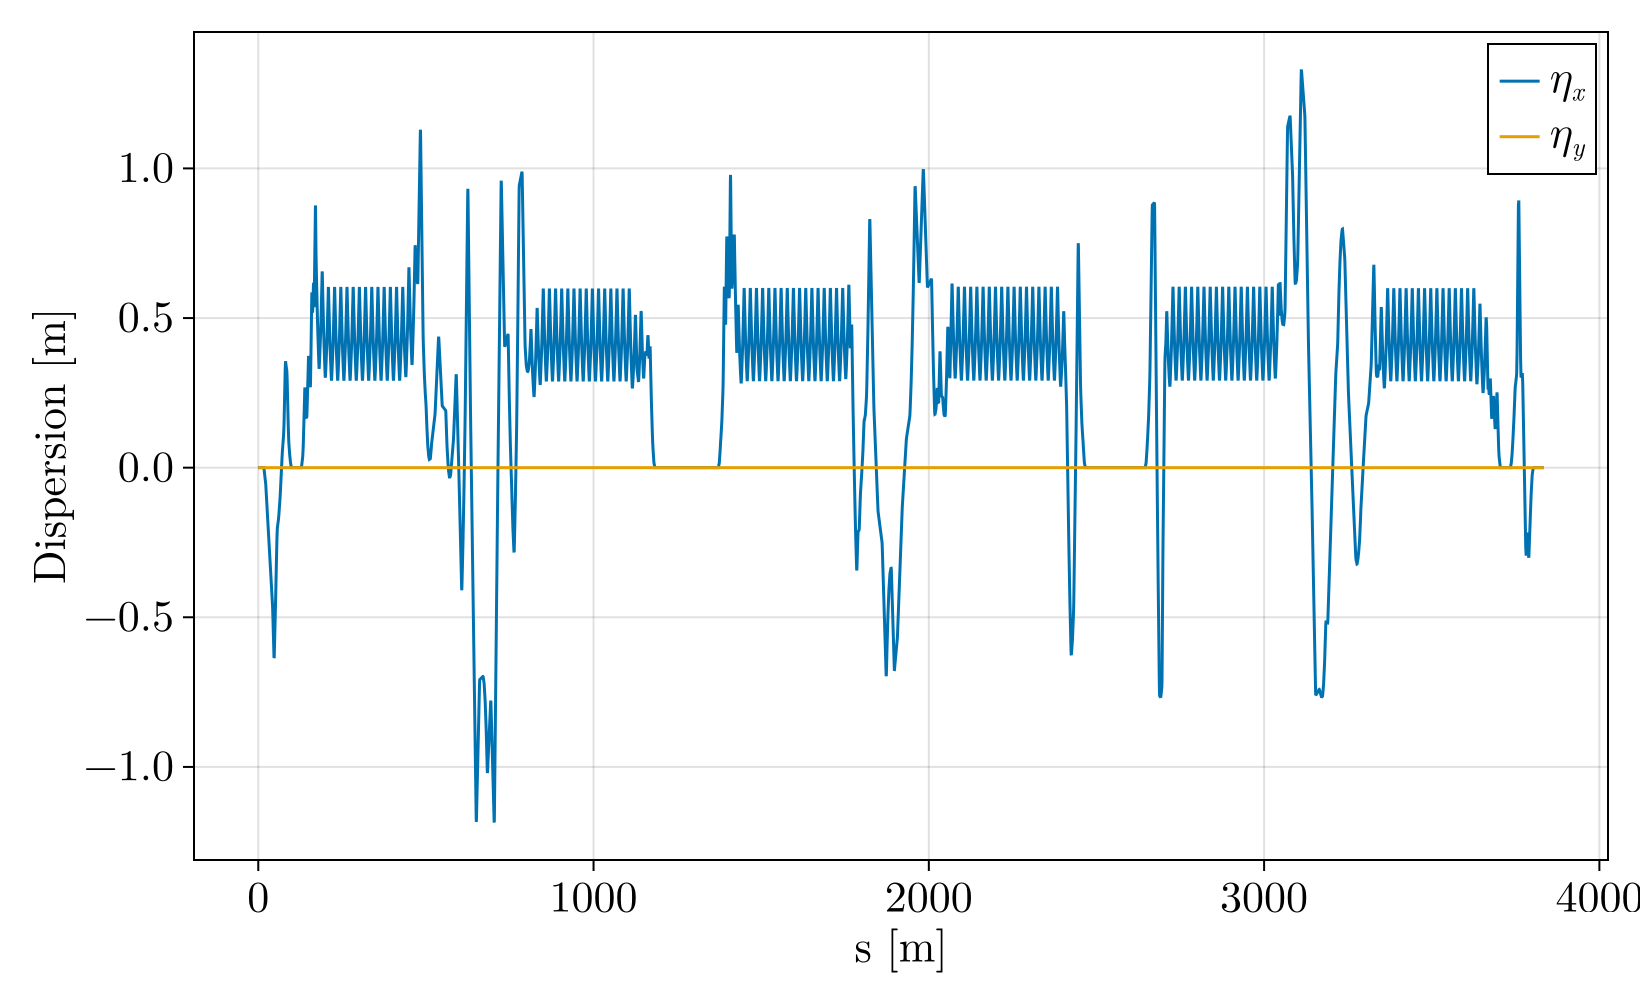

In [59]:
eta_x = map(x -> x[[0, 0, 0, 0, 0, 1]], t.orbit_x)
eta_y = map(x -> x[[0, 0, 0, 0, 0, 1]], t.orbit_y)

fig = Figure(fontsize=22, size=(820, 500))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Dispersion [m]")

lines!(ax, t.s, eta_x, label=L"\eta_x")
lines!(ax, t.s, eta_y, label=L"\eta_y")
axislegend(ax, position=:rt)

fig

To obtain higher-order quantities, use a higher-order TPSA descriptor. `Descriptor(6, 2)` means six variables, truncated at second order. This is enough for the second-order closed-orbit term and the first chromatic derivative of the beta functions. For the second derivative of the beta functions, we also compute a third-order descriptor below.

In [60]:
D2 = Descriptor(6, 2)
tw2 = twiss(ring; GTPSA_descriptor=D2)
t2 = tw2.table
t2.orbit_x[1]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=2)
 COEFFICIENT             ORDER   EXPONENTS
2.4442493994496515E-016    0     0 0  0 0  0 0
4.7436543508558284E-008    1     0 0  0 0  0 1
-6.9849628570669120E+000    2     0 0  0 0  0 2


The display above now includes the $\delta^2$ coefficient. At the first table row, which is the beginning of the ring in this lattice, the coefficient of $\delta$ gives the first derivative, and twice the coefficient of $\delta^2$ gives the second derivative.

Here `s_start` identifies the location, while the three following values are the Taylor coefficients evaluated at that location.

In [61]:
s_start = t2.s[1]
xco_start = t2.orbit_x[1][[0, 0, 0, 0, 0, 0]]
dxco_ddelta_start = t2.orbit_x[1][[0, 0, 0, 0, 0, 1]]
d2xco_ddelta2_start = 2 * t2.orbit_x[1][[0, 0, 0, 0, 0, 2]]

(s_start=s_start,
 xco_start=xco_start,
 dxco_ddelta_start=dxco_ddelta_start,
 d2xco_ddelta2_start=d2xco_ddelta2_start)

(s_start = 0.0, xco_start = 2.4442493994496515e-16, dxco_ddelta_start = 4.7436543508558284e-8, d2xco_ddelta2_start = -13.969925714133824)

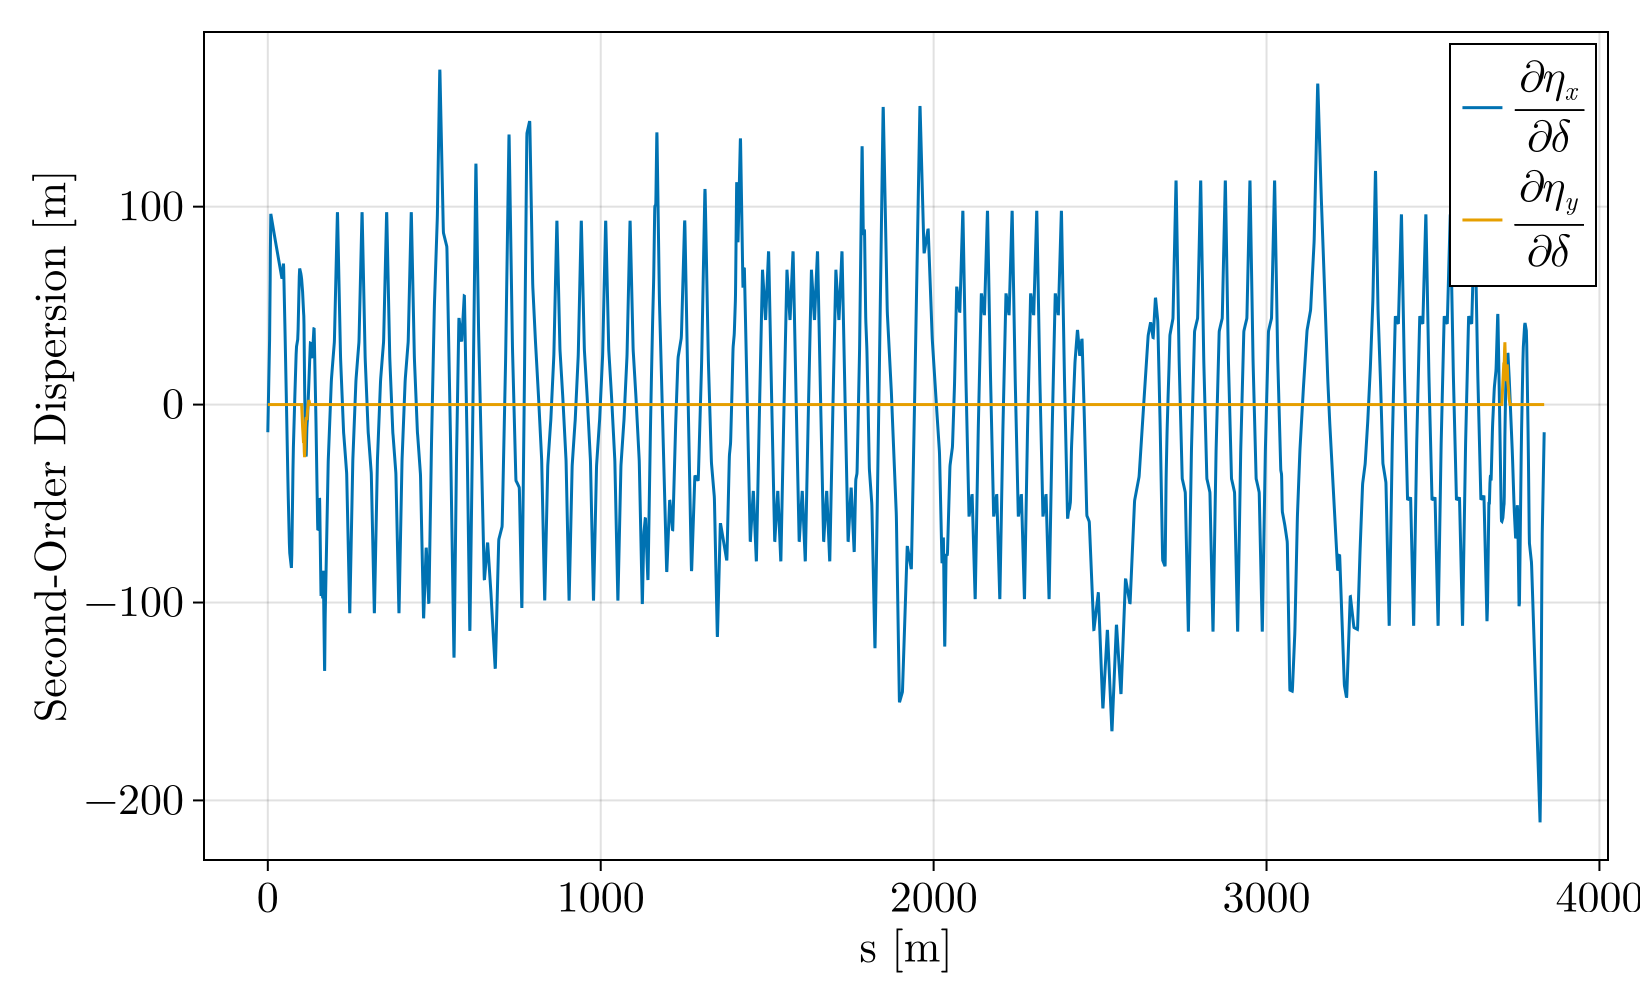

In [62]:
# The coefficient of delta^2 contains the Taylor factor 1/2!.
deta_ddelta_x = map(x -> 2 * x[[0, 0, 0, 0, 0, 2]], t2.orbit_x)
deta_ddelta_y = map(x -> 2 * x[[0, 0, 0, 0, 0, 2]], t2.orbit_y)

fig = Figure(fontsize=22, size=(820, 500))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Second-Order Dispersion [m]")

lines!(ax, t2.s, deta_ddelta_x, label=L"\frac{\partial \eta_x}{\partial \delta}")
lines!(ax, t2.s, deta_ddelta_y, label=L"\frac{\partial \eta_y}{\partial \delta}")
axislegend(ax, position=:rt)

fig

For the closed orbit, `Descriptor(6, 2)` is enough to obtain both the first and second derivatives with respect to $\delta$. For beta functions, the first chromatic derivative is obtained from `t2`, but the second derivative of beta is extracted below from `t3`, using `Descriptor(6, 3)`.

In [63]:
D3 = Descriptor(6, 3)
tw3 = twiss(ring; GTPSA_descriptor=D3)
t3 = tw3.table;

The same coefficient extraction works for the beta functions. Here we extract the design beta, the first derivative with respect to $\delta$, and the second derivative with respect to $\delta$.

For inspection, `t2.beta_1[1]` shows the TPSA object at the first lattice position.

In [64]:
t2.beta_1[1]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=2)
 COEFFICIENT             ORDER   EXPONENTS
5.8999920399335681E-001    0     0 0  0 0  0 0
-4.1353894277545145E+000    1     0 0  0 0  0 1


In [65]:
beta_1 = map(x -> x[[0, 0, 0, 0, 0, 0]], t2.beta_1)
beta_2 = map(x -> x[[0, 0, 0, 0, 0, 0]], t2.beta_2)

dbeta_ddelta_1 = map(x -> x[[0, 0, 0, 0, 0, 1]], t2.beta_1)
dbeta_ddelta_2 = map(x -> x[[0, 0, 0, 0, 0, 1]], t2.beta_2)

d2beta_ddelta2_1 = map(x -> 2 * x[[0, 0, 0, 0, 0, 2]], t3.beta_1)
d2beta_ddelta2_2 = map(x -> 2 * x[[0, 0, 0, 0, 0, 2]], t3.beta_2)

nothing

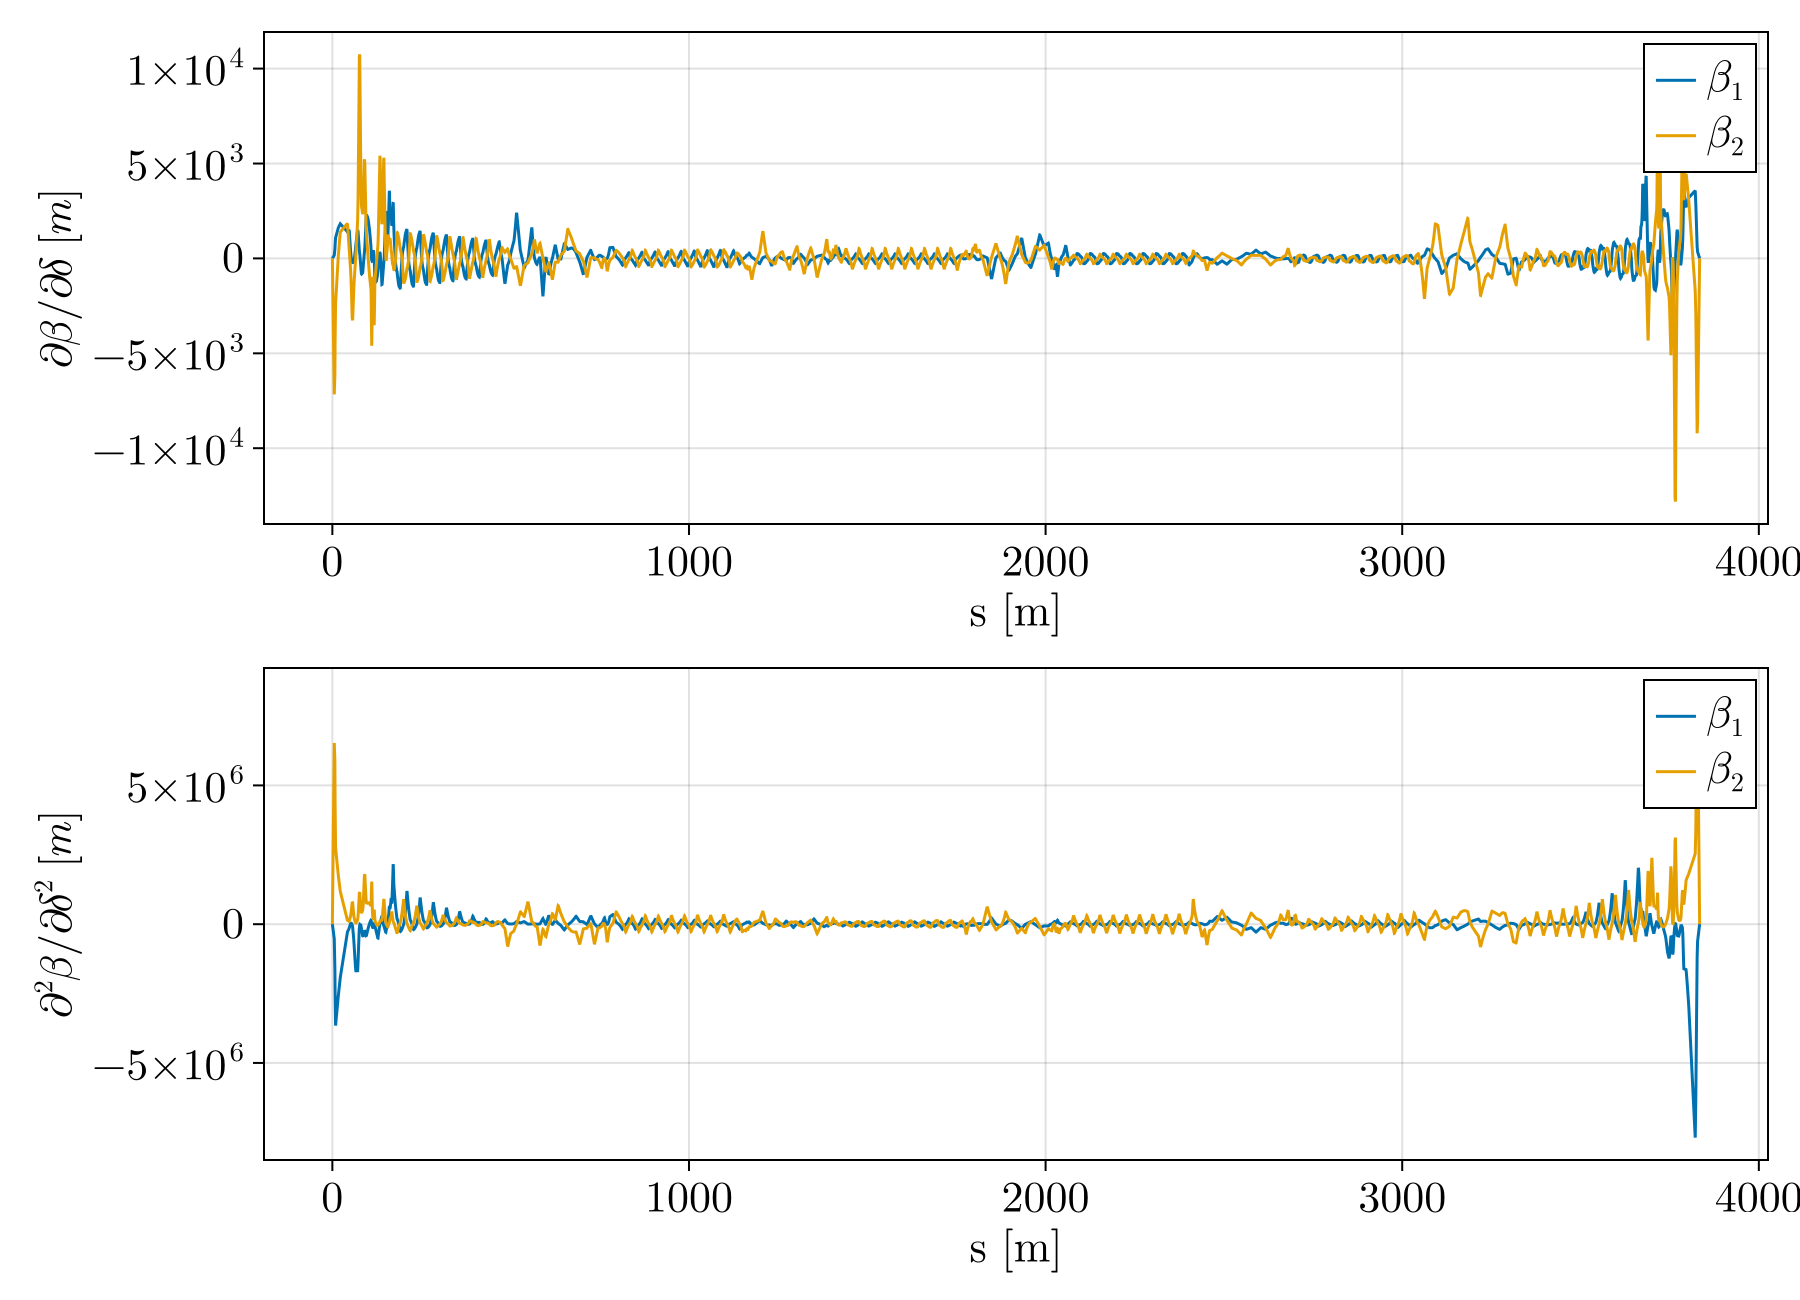

In [66]:
fig = Figure(fontsize=22, size=(900, 650))

ax1 = Axis(fig[1, 1], xlabel="s [m]", ylabel=L"\partial\beta/\partial\delta \; [m]")
lines!(ax1, t2.s, dbeta_ddelta_1, label=L"\beta_1")
lines!(ax1, t2.s, dbeta_ddelta_2, label=L"\beta_2")
axislegend(ax1, position=:rt)

ax2 = Axis(fig[2, 1], xlabel="s [m]", ylabel=L"\partial^2\beta/\partial\delta^2 \; [m]")
lines!(ax2, t3.s, d2beta_ddelta2_1, label=L"\beta_1")
lines!(ax2, t3.s, d2beta_ddelta2_2, label=L"\beta_2")
axislegend(ax2, position=:rt)

fig

## 13.3 Examples: Chromatic Beats and Montague Functions

A common way to show the chromatic distortion of the beta function is the normalized beta derivative

$$
\frac{1}{\beta}\frac{\partial \beta}{\partial \delta}.
$$

This is often called chromatic beta-beat.

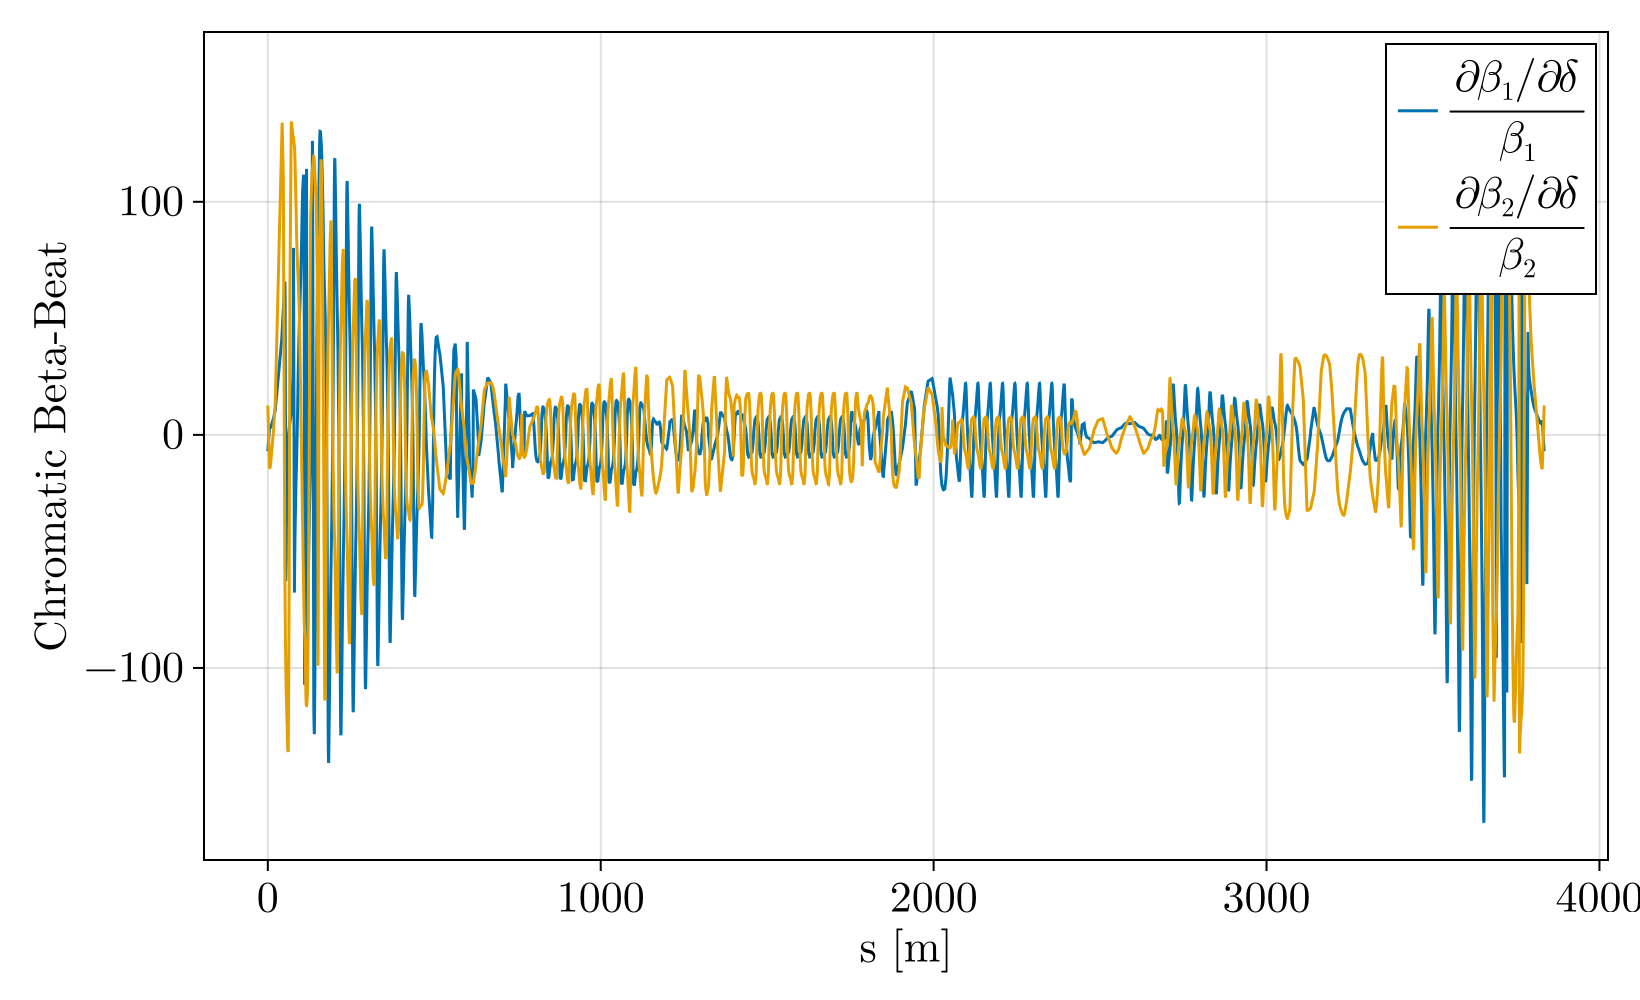

In [67]:
fig = Figure(fontsize=22, size=(820, 500))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Chromatic Beta-Beat")

lines!(ax, t2.s, dbeta_ddelta_1 ./ beta_1, label=L"\frac{\partial\beta_1/\partial\delta}{\beta_1}")
lines!(ax, t2.s, dbeta_ddelta_2 ./ beta_2, label=L"\frac{\partial\beta_2/\partial\delta}{\beta_2}")
axislegend(ax, position=:rt)

fig

The Montague functions combine the chromatic distortion of both $\alpha$ and $\beta$:

$$
W = \sqrt{A^2 + B^2},
$$

$$
A = \frac{\partial\alpha}{\partial\delta} - \frac{\alpha}{\beta}\frac{\partial\beta}{\partial\delta}, \qquad
B = \frac{1}{\beta}\frac{\partial\beta}{\partial\delta}.
$$

In achromatic regions, these functions are useful phase-invariant diagnostics of chromatic optical distortion.

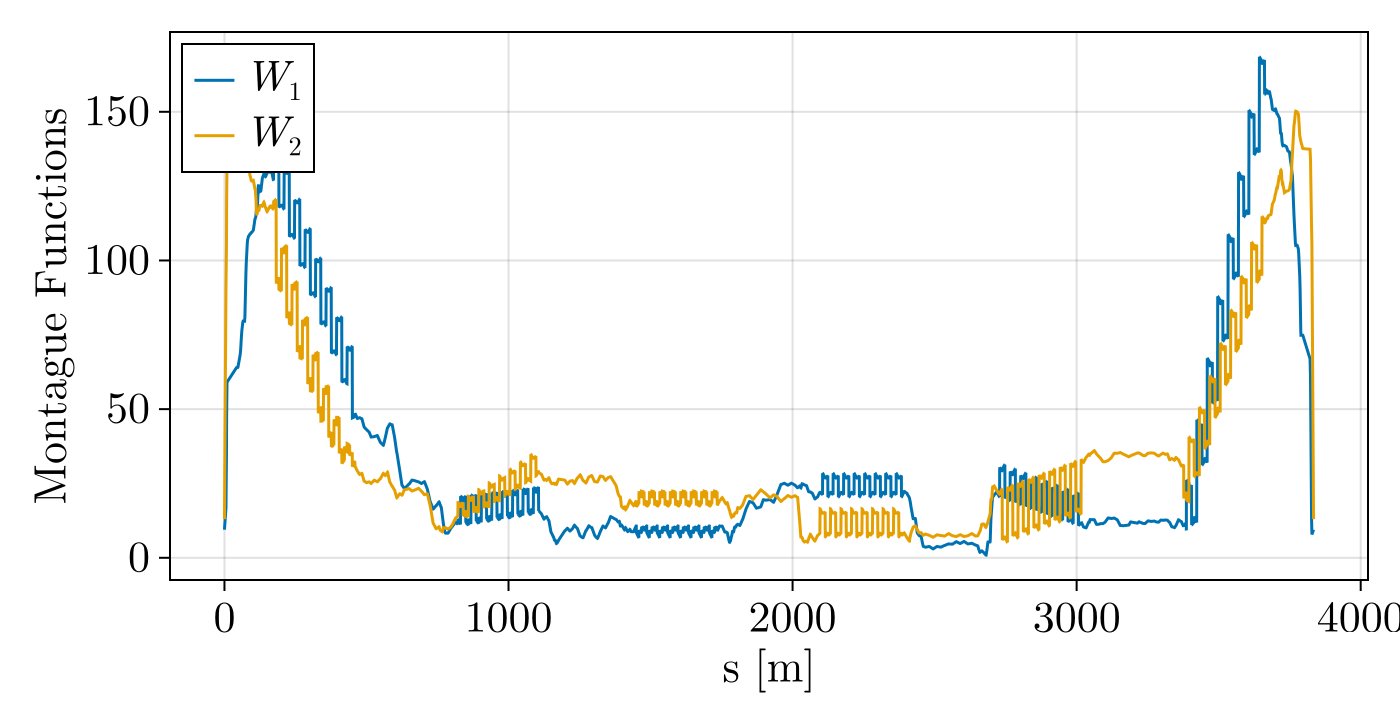

In [68]:
# extract derivatives used in W functions
alpha_1 = map(x -> x[[0, 0, 0, 0, 0, 0]], t2.alpha_1)
alpha_2 = map(x -> x[[0, 0, 0, 0, 0, 0]], t2.alpha_2)

dalpha_ddelta_1 = map(x -> x[[0, 0, 0, 0, 0, 1]], t2.alpha_1)
dalpha_ddelta_2 = map(x -> x[[0, 0, 0, 0, 0, 1]], t2.alpha_2)
# calculate W functions
W_1 = @. sqrt((dalpha_ddelta_1 - alpha_1 / beta_1 * dbeta_ddelta_1)^2 + (dbeta_ddelta_1 / beta_1)^2)
W_2 = @. sqrt((dalpha_ddelta_2 - alpha_2 / beta_2 * dbeta_ddelta_2)^2 + (dbeta_ddelta_2 / beta_2)^2)

# plot figure
fig = Figure(fontsize=22, size=(700, 360))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Montague Functions")

lines!(ax, t2.s, W_1, label=L"W_1")
lines!(ax, t2.s, W_2, label=L"W_2")
axislegend(ax, position=:lt)

fig

The same idea can be extended to higher order. For the second-order Montague functions below, the coefficient of $\delta^2$ is used directly because the definition includes the Taylor factor $1/2!$.

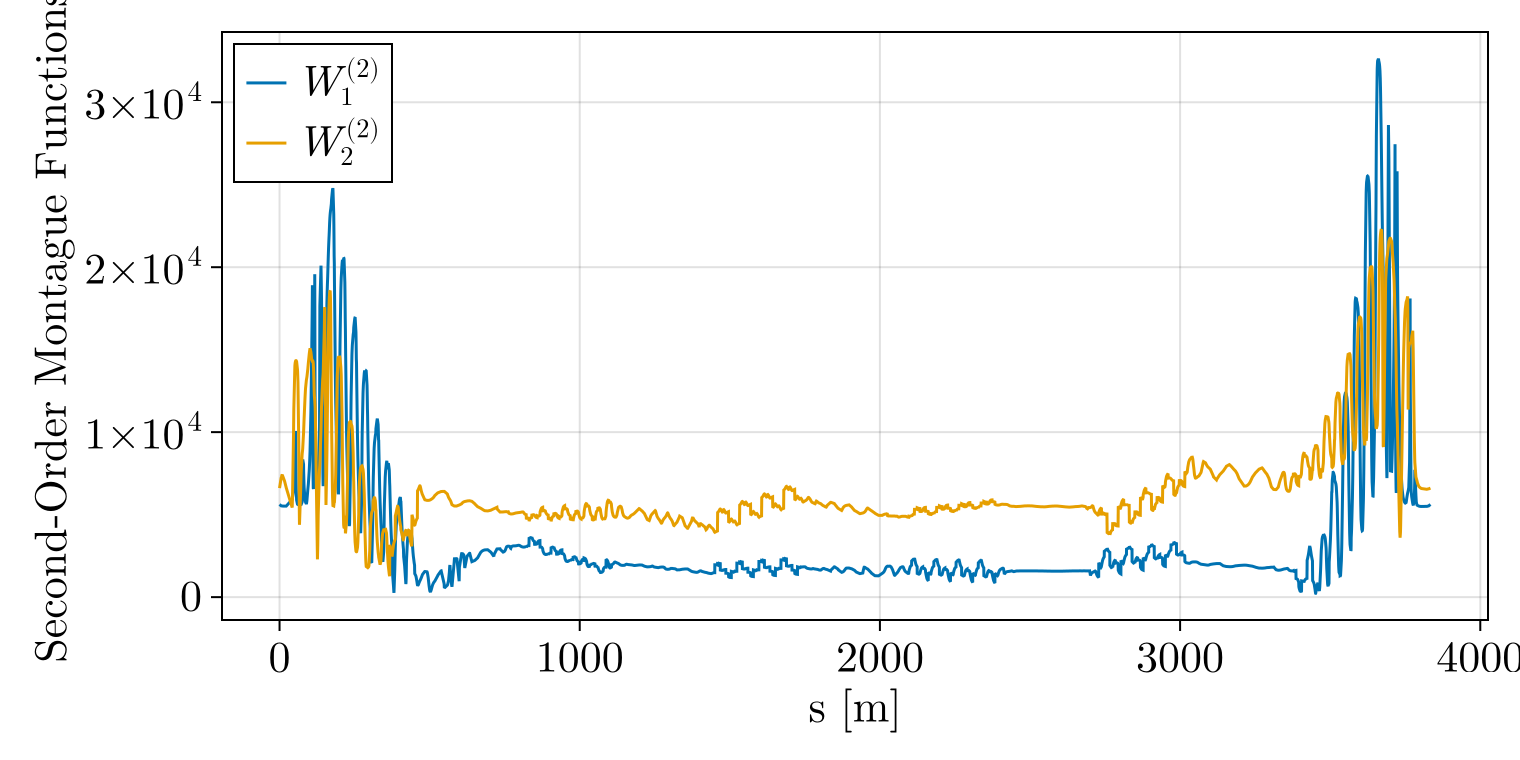

In [69]:
beta_1_d3 = map(x -> x[[0, 0, 0, 0, 0, 0]], t3.beta_1)
beta_2_d3 = map(x -> x[[0, 0, 0, 0, 0, 0]], t3.beta_2)
alpha_1_d3 = map(x -> x[[0, 0, 0, 0, 0, 0]], t3.alpha_1)
alpha_2_d3 = map(x -> x[[0, 0, 0, 0, 0, 0]], t3.alpha_2)

d2alpha_coeff_1 = map(x -> x[[0, 0, 0, 0, 0, 2]], t3.alpha_1)
d2alpha_coeff_2 = map(x -> x[[0, 0, 0, 0, 0, 2]], t3.alpha_2)
d2beta_coeff_1 = map(x -> x[[0, 0, 0, 0, 0, 2]], t3.beta_1)
d2beta_coeff_2 = map(x -> x[[0, 0, 0, 0, 0, 2]], t3.beta_2)

W2_1 = @. sqrt((d2alpha_coeff_1 - alpha_1_d3 / beta_1_d3 * d2beta_coeff_1)^2 + (d2beta_coeff_1 / beta_1_d3)^2)
W2_2 = @. sqrt((d2alpha_coeff_2 - alpha_2_d3 / beta_2_d3 * d2beta_coeff_2)^2 + (d2beta_coeff_2 / beta_2_d3)^2)

# plot figure
fig = Figure(fontsize=22, size=(760, 380))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Second-Order Montague Functions")

lines!(ax, t3.s, W2_1, label=L"W^{(2)}_1")
lines!(ax, t3.s, W2_2, label=L"W^{(2)}_2")
axislegend(ax, position=:lt)

fig

## 13.4 Tunes

The tunes returned by `twiss` are also TPSA objects. In the phasor basis, the transverse variables are written in terms of $\sqrt{J}e^{\pm i\phi}$. This means that terms with the same exponent in a conjugate pair correspond to powers of the action $J$.

For example, a monomial with exponents `1 1` in one transverse mode corresponds to

$$
(\sqrt{J}e^{-i\phi})(\sqrt{J}e^{+i\phi}) = J.
$$

Therefore, the coefficient of that term gives an amplitude-dependent tune shift such as $\partial Q_x/\partial J_x$ or $\partial Q_x/\partial J_y$, depending on which mode pair is used.

In [71]:
GTPSA.show_eps = 1e-10

tw3.tunes

nothing

To plot tune variation with momentum deviation, compute the tune TPSA to higher order and evaluate it as an ordinary Julia function of $\delta$. The keyword `at=[]` skips the full Twiss table and computes only the global quantities, which makes this faster.

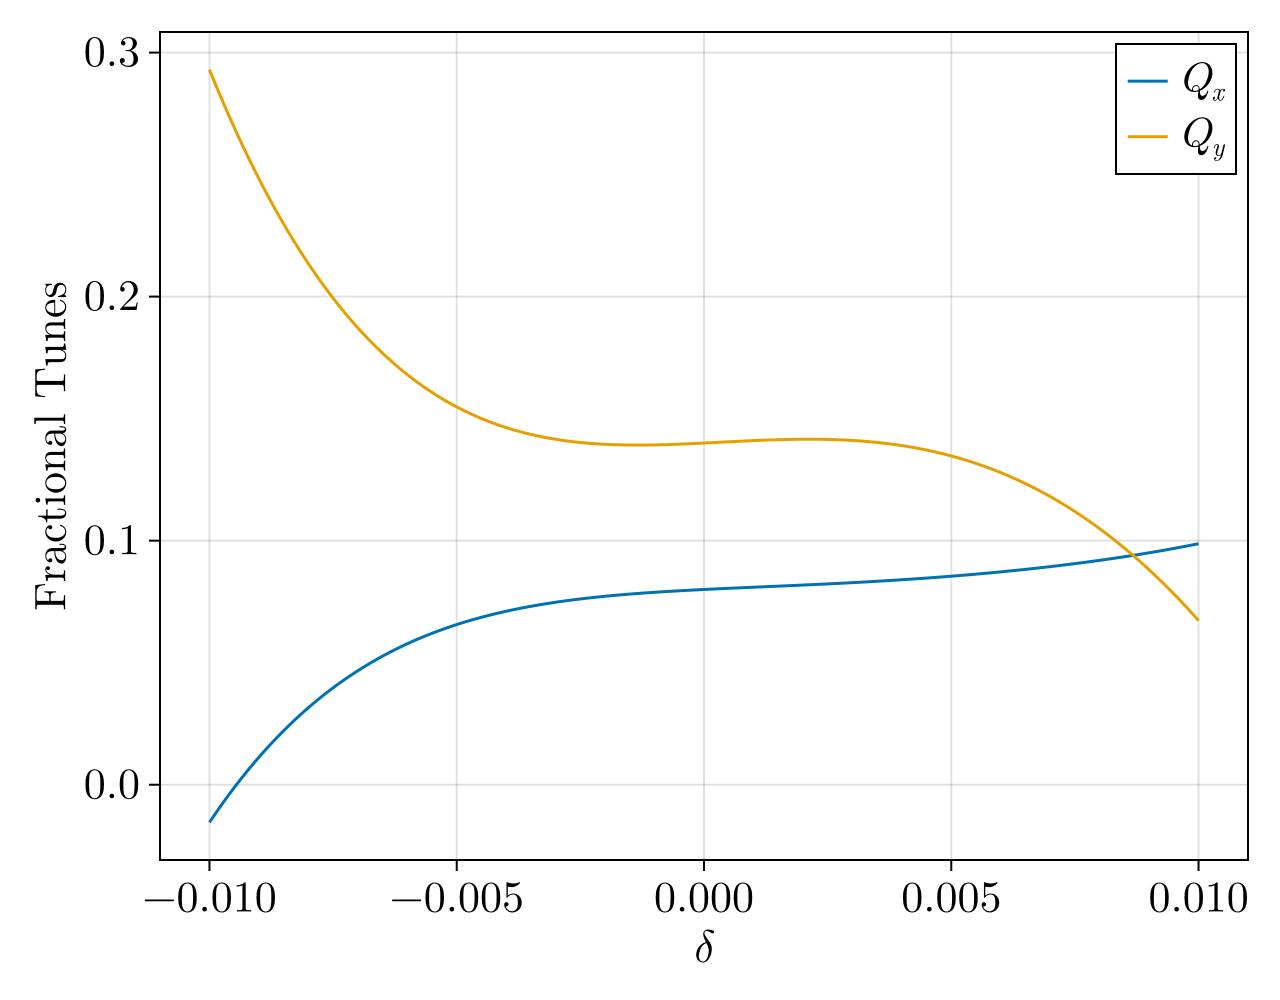

In [72]:
tw_tunes = twiss(ring; GTPSA_descriptor=Descriptor(6, 6), at=[])
delta = (-1:0.01:1) .* 1e-2

Qx = tw_tunes.tunes[1]
Qy = tw_tunes.tunes[2]

fig = Figure(fontsize=22, size=(640, 500))
ax = Axis(fig[1, 1], xlabel=L"\delta", ylabel="Fractional Tunes")

lines!(ax, delta, Qx.(0, 0, 0, 0, 0, delta), label=L"Q_x")
lines!(ax, delta, Qy.(0, 0, 0, 0, 0, delta), label=L"Q_y")
axislegend(ax, position=:rt)

fig

## 13.5 Analyzing Spin

SciBmad can also include spin in the nonlinear Twiss calculation. Setting `spin=true` adds the stable spin direction $\hat n$ to the Twiss table. The derivative

$$
\frac{\partial \hat n}{\partial \delta}
$$

measures how sensitively the spin direction changes with momentum deviation.

In [73]:
tw_spin = twiss(ring; spin=true)

Twiss:
 coasting_beam = true
 tunes[1:4]    = [Qx, Qy, slip, Qspin]
 table         has columns: beamline_index, name, s, phi_1, beta_1, alpha_1, phi_2, beta_2, alpha_2, phi_3, gamma_c, c11, c12, c21, c22, orbit_x, orbit_px, orbit_y, orbit_py, orbit_z, orbit_pz, n_x, n_y, n_z

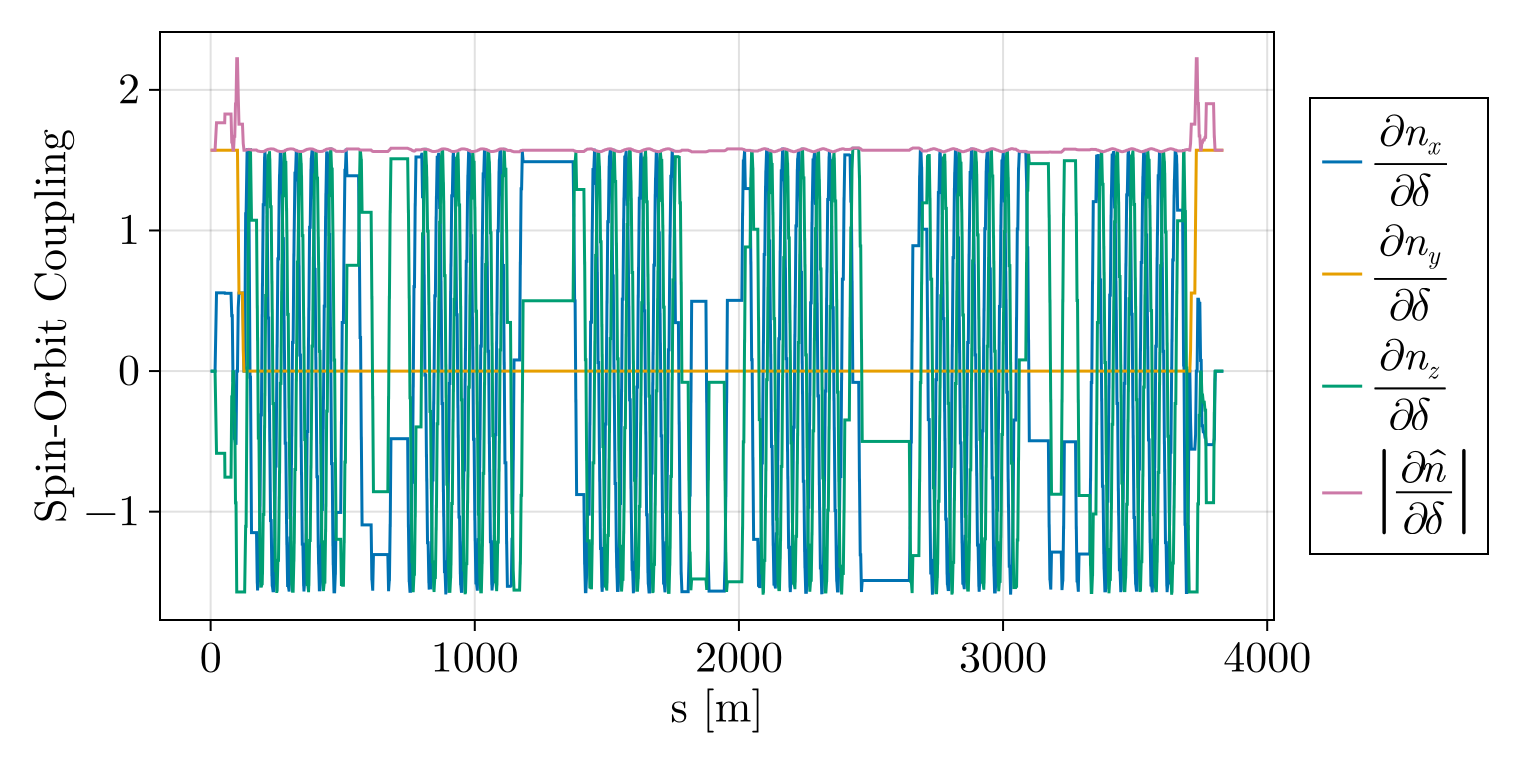

In [74]:
ts = tw_spin.table
dn_ddelta_x = -map(x -> x[6], ts.n_x)
dn_ddelta_y = -map(x -> x[6], ts.n_y)
dn_ddelta_z = -map(x -> x[6], ts.n_z)
dn_ddelta_amp = sqrt.(vec(sum(abs2, [dn_ddelta_x dn_ddelta_y dn_ddelta_z], dims=2)))

fig = Figure(fontsize=22, size=(760, 380))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="Spin-Orbit Coupling")

lines!(ax, ts.s, dn_ddelta_x, label=L"\frac{\partial n_x}{\partial\delta}")
lines!(ax, ts.s, dn_ddelta_y, label=L"\frac{\partial n_y}{\partial\delta}")
lines!(ax, ts.s, dn_ddelta_z, label=L"\frac{\partial n_z}{\partial\delta}")
lines!(ax, ts.s, dn_ddelta_amp, label=L"\left|\frac{\partial\hat{n}}{\partial\delta}\right|")
Legend(fig[1, 2], ax)

fig

## 13.6 Exercises

1. **Derivative order check.** Use `Descriptor(6, 1)`, `Descriptor(6, 2)`, and `Descriptor(6, 3)` to recompute the Twiss table. For each descriptor order, check which of the following quantities can be extracted from the TPSA coefficients: $\partial x_{co}/\partial\delta$, $\partial^2 x_{co}/\partial\delta^2$, $\partial\beta/\partial\delta$, and $\partial^2\beta/\partial\delta^2$. Explain why the beta-function derivatives require one higher order than the closed-orbit derivatives.

2. **Optics sensitivity.** Find the location where $|\partial\beta_x/\partial\delta|/\beta_x$ is largest. What element or region of the ring is closest to this maximum? Repeat the same check for the vertical plane.

3. **Spin sensitivity.** Find the location where $|\partial\hat{n}/\partial\delta|$ is largest. Compare this location with the strongest chromatic beta-beating region. Are they near the same part of the ring? What might this suggest about the difference between optics sensitivity and spin sensitivity?

4. **Change the expansion variable.** Instead of extracting coefficients with respect to $\delta$, extract first-order coefficients with respect to another TPSA variable, such as $x$ or $y$. For example, compare coefficients with exponent vectors `[1, 0, 0, 0, 0, 0]`, `[0, 0, 1, 0, 0, 0]`, and `[0, 0, 0, 0, 0, 1]`. What physical information is carried by each choice of expansion variable?